In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("bike_sales_100k.csv")
df.head()


,Sale_ID,Date,Customer_ID,Bike_Model,Price,Quantity,Store_Location,Salesperson_ID,Payment_Method,Customer_Age,Customer_Gender
0,1,11-07-2022,9390,Cruiser,318.32,1,Philadelphia,589,Apple Pay,70,Female
1,2,03-05-2024,3374,Hybrid Bike,3093.47,4,Chicago,390,Apple Pay,37,Male
2,3,01-09-2022,2689,Folding Bike,4247.99,3,San Antonio,338,PayPal,59,Female
3,4,28-09-2022,3797,Mountain Bike,1722.01,3,San Antonio,352,Apple Pay,19,Male
4,5,05-01-2021,1633,BMX,3941.44,3,Philadelphia,580,PayPal,67,Female


In [39]:
df.duplicated().sum()
df.isnull().sum()


,0
Sale_ID,0
Date,0
Customer_ID,0
Bike_Model,0
Price,0
Quantity,0
Store_Location,0
Salesperson_ID,0
Payment_Method,0
Customer_Age,0


In [6]:
# Convert date
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Create derived columns
df['Revenue'] = df['Price'] * df['Quantity']
df['Month'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')
df.head()

,Sale_ID,Date,Customer_ID,Bike_Model,Price,Quantity,Store_Location,Salesperson_ID,Payment_Method,Customer_Age,Customer_Gender,Revenue,Month,Quarter
0,1,2022-07-11,9390,Cruiser,318.32,1,Philadelphia,589,Apple Pay,70,Female,318.32,2022-07,2022Q3
1,2,2024-05-03,3374,Hybrid Bike,3093.47,4,Chicago,390,Apple Pay,37,Male,12373.88,2024-05,2024Q2
2,3,2022-09-01,2689,Folding Bike,4247.99,3,San Antonio,338,PayPal,59,Female,12743.97,2022-09,2022Q3
3,4,2022-09-28,3797,Mountain Bike,1722.01,3,San Antonio,352,Apple Pay,19,Male,5166.03,2022-09,2022Q3
4,5,2021-01-05,1633,BMX,3941.44,3,Philadelphia,580,PayPal,67,Female,11824.32,2021-01,2021Q1


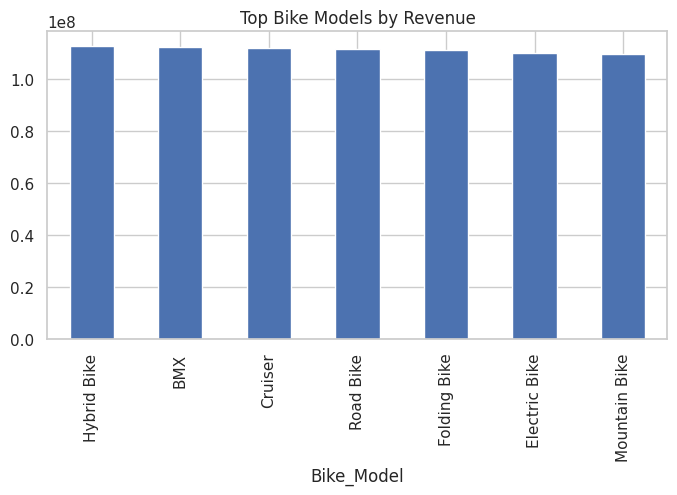

In [34]:
#Top bike models by revenue
model_perf = df.groupby('Bike_Model').agg(
    Total_Revenue=('Revenue', 'sum'),
    Units_Sold=('Quantity', 'sum'),
    Avg_Price=('Price', 'mean')
).sort_values('Total_Revenue', ascending=False)
model_perf.head(10)
model_perf['Total_Revenue'].head(10).plot(kind='bar', figsize=(8,4), title='Top Bike Models by Revenue')
plt.show()

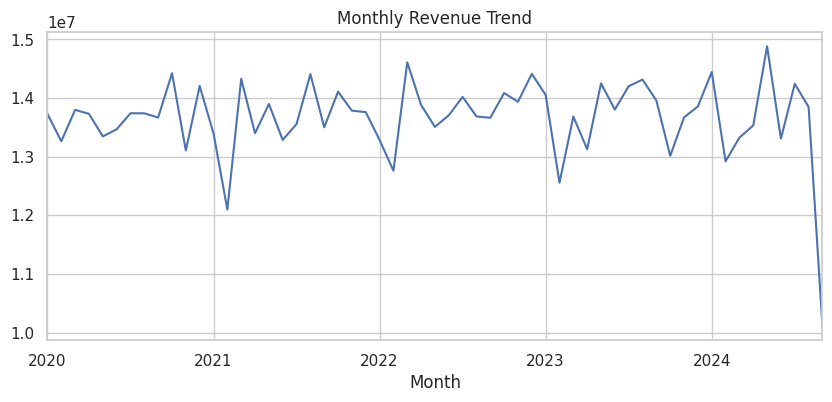

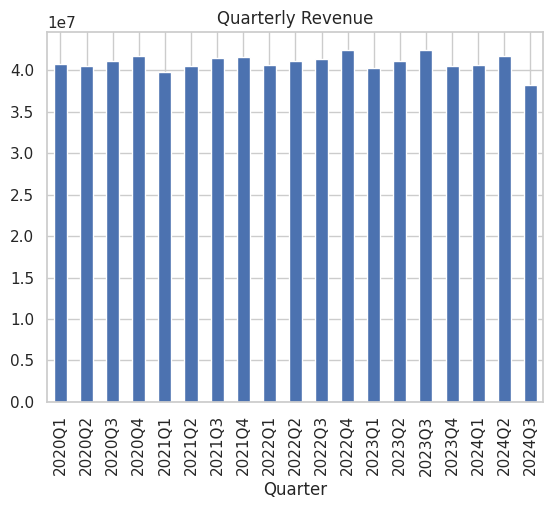

In [33]:
#Monthly / Quarterly sales trends
monthly_sales = df.groupby('Month')['Revenue'].sum()
quarterly_sales = df.groupby('Quarter')['Revenue'].sum()
monthly_sales.plot(figsize=(10,4), title='Monthly Revenue Trend')
plt.show()
quarterly_sales.plot(kind='bar', title='Quarterly Revenue')
plt.show()


In [32]:
#Store performance by revenue
store_perf = df.groupby('Store_Location').agg(
    Total_Revenue=('Revenue', 'sum'),
    Avg_Transaction=('Revenue', 'mean'),
    Sales_Volume=('Quantity', 'sum')
).sort_values('Total_Revenue', ascending=False)
store_perf

,Total_Revenue,Avg_Transaction,Sales_Volume
Store_Location,,,
New York,1.135925e+08,7825.867994,43688
Phoenix,1.118604e+08,7776.184888,42901
Philadelphia,1.117658e+08,7799.429829,42698
Houston,1.104270e+08,7804.582825,42607
Chicago,1.103881e+08,7769.982335,42614
Los Angeles,1.103409e+08,7817.829891,42492
San Antonio,1.100595e+08,7696.467094,42711


In [31]:
#Top-performing salespeople
sales_perf = df.groupby('Salesperson_ID').agg(
    Total_Revenue=('Revenue', 'sum'),
    Units_Sold=('Quantity', 'sum'),
    Avg_Transaction=('Revenue', 'mean')
).sort_values('Total_Revenue', ascending=False)
sales_perf.head(10)

,Total_Revenue,Units_Sold,Avg_Transaction
Salesperson_ID,,,
794,1196096.15,441,8543.543929
500,1137238.34,398,8954.632598
605,1125911.79,401,8727.998372
655,1123963.90,406,8514.878030
914,1123278.39,405,8445.702180
758,1105827.98,396,8506.369077
419,1105377.27,404,8772.835476
894,1101144.40,414,7979.307246
540,1100962.64,381,8601.270625


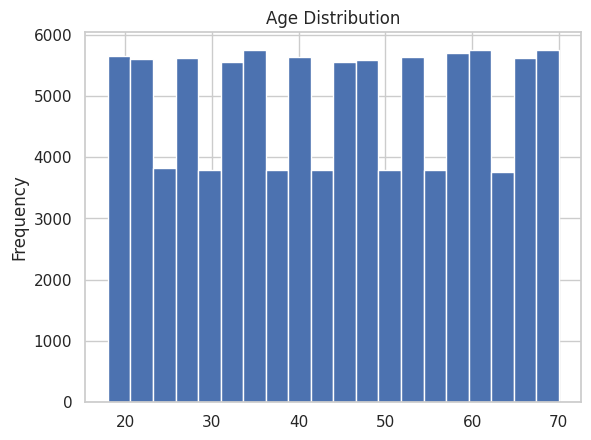

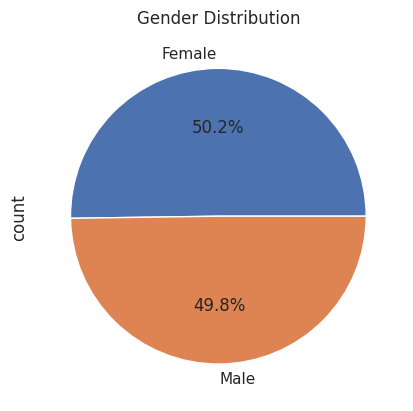

In [30]:
#Customer demographics
df['Customer_Age'].plot(kind='hist', bins=20, title='Age Distribution')
plt.show()
df['Customer_Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Gender Distribution')
plt.show()

In [29]:
bins = [0, 25, 35, 45, 55, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55+']
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels)

age_spending = df.groupby('Age_Group').agg(
    Avg_Spend=('Revenue', 'mean'),
    Total_Revenue=('Revenue', 'sum')
)
age_spending

/tmp/ipython-input-177015814.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_spending = df.groupby('Age_Group').agg(


,Avg_Spend,Total_Revenue
Age_Group,,
<25,7743.246905,1.168301e+08
25-34,7765.398184,1.460205e+08
35-44,7838.616907,1.480166e+08
45-54,7846.722996,1.472516e+08
55+,7741.500805,2.203154e+08


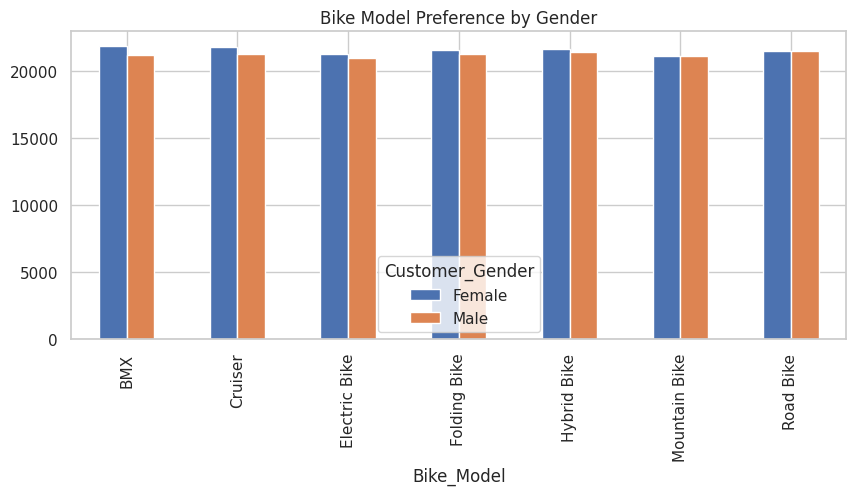

In [27]:
#Gender-based bike preferences
gender_product = pd.crosstab(df['Bike_Model'], df['Customer_Gender'], values=df['Quantity'], aggfunc='sum')
gender_product
gender_product.plot(kind='bar', figsize=(10,4))
plt.title('Bike Model Preference by Gender')
plt.show()

In [28]:
#Payment method preference
payment_perf = df.groupby('Payment_Method').agg(
    Transactions=('Revenue', 'count'),
    Avg_Value=('Revenue', 'mean')
)
payment_perf


,Transactions,Avg_Value
Payment_Method,,
Apple Pay,16751,7788.212169
Cash,16692,7765.622147
Credit Card,16653,7798.845876
Debit Card,16738,7798.383285
Google Pay,16613,7798.532305
PayPal,16553,7756.273246


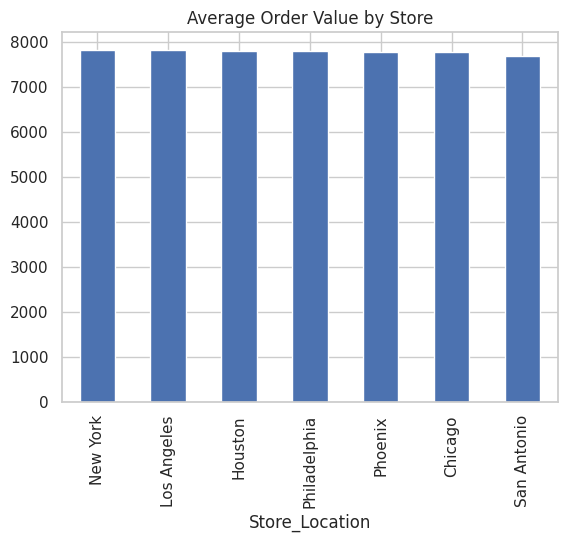

In [36]:
#Average transaction value by store
aov_store = df.groupby('Store_Location')['Revenue'].mean().sort_values(ascending=False)
aov_store
aov_store.plot(kind='bar', title='Average Order Value by Store')
plt.show()

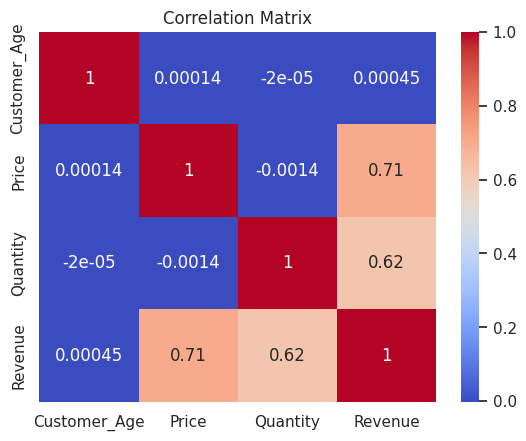

In [38]:
#Correlation: age – model – price
corr_df = df[['Customer_Age', 'Price', 'Quantity', 'Revenue']].corr()
corr_df
sns.heatmap(corr_df, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()